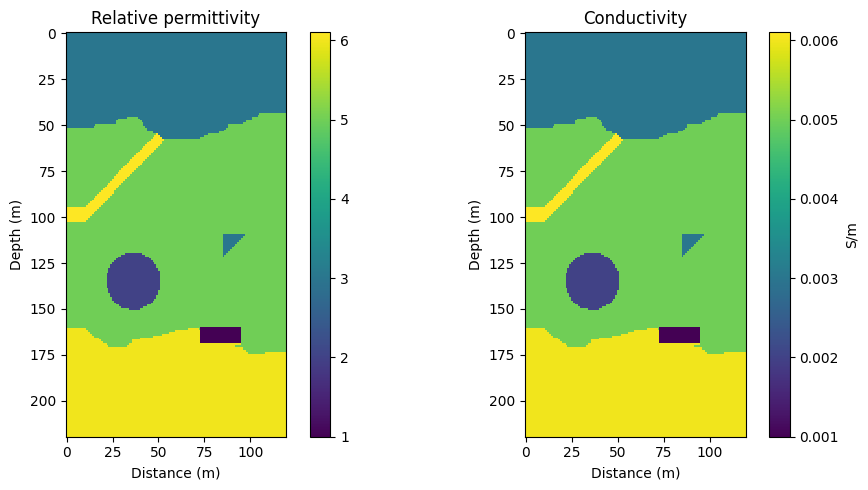

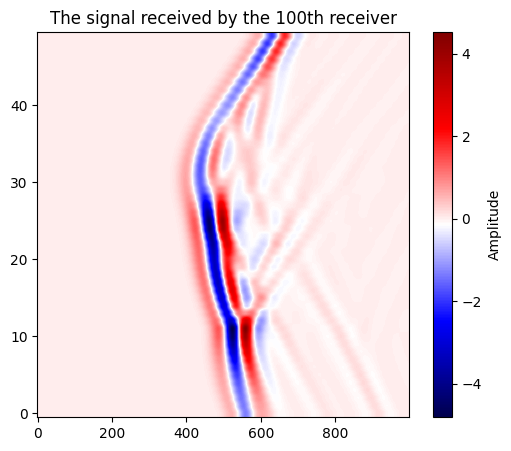

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import DeepGPR1
import matplotlib.pyplot as plt
from skimage import filters
import time

# Set up the parameters and models
torch.cuda.set_device(4)
device=torch.device("cuda")
dx=0.05
dt=1e-10
nt=1000

source_location=torch.zeros((50,1,3),device=device,dtype=torch.int)
source_location[:,0,0]=torch.arange(10, 210, 4)
source_location[:,:,1]=10

receiver_location=torch.zeros((50,200,3),device=device,dtype=torch.int)
receiver_location[:,:,0]=torch.arange(10, 210, 1).repeat(50,1)
receiver_location[:,:,1]=110


freq=1e8
peak_time = 1 / freq
source_amplitudes = torch.zeros((1,nt,1),device=device)
source_amplitudes[0,:,0]=DeepGPR1.ricker(freq, nt, dt, peak_time).to(device)


ert = F.pad(torch.tensor(np.load('2DFWImodel.npy')).unsqueeze(0).unsqueeze(0), pad=(10, 10, 10, 10), mode='replicate').squeeze()
set = ert.clone()*0.001

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  
im1 = axes[0].imshow(ert.cpu().numpy(),
                     cmap='viridis',
                     interpolation='nearest',
                     aspect='equal')
cbar1 = plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Relative permittivity')
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Depth (m)')

im2 = axes[1].imshow(set.cpu().numpy(),
                     cmap='viridis',
                     interpolation='nearest',
                     aspect='equal')
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('S/m')
axes[1].set_title('Conductivity')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Depth (m)')

plt.tight_layout()
plt.show()


#Forward modeling
r_obs = DeepGPR1.compute(
    device=device, dx=dx, dt=dt, 
    source_amplitudes=source_amplitudes,
    source_location=source_location, 
    receiver_location=receiver_location, 
    er=ert, se=set
)

plt.figure(figsize=(6, 5)) 
im = plt.imshow(r_obs[-1][:,:,99].detach().cpu().numpy(), cmap='seismic', origin='lower',aspect='auto')
plt.colorbar(im, label='Amplitude') 
plt.title("The signal received by the 100th receiver") 
plt.show()


In [ ]:
er=torch.tensor(filters.gaussian(ert,sigma=20),device=device)
se=torch.tensor(filters.gaussian(set,sigma=20),device=device)

optimiser_phase1 = torch.optim.Adam([
    {'params': er, 'lr': 0.5},
])

optimiser_phase2 = torch.optim.Adam([
    {'params': er, 'lr': 0.2},
    {'params': se, 'lr': 0.0001}
])
phase1_epochs = 50 
losses = []
n_epochs=201

loss_fnmse = torch.nn.MSELoss()
loss_fnl1= torch.nn.L1Loss()

start_time = time.time()


tv_criterion = DeepGPR1.TVRegularization(weight_ep=100,weight_sigma=0.00001).to(device)

Epoch 0, Loss: 1358459648.00, Epoch Time: 0.86s, Total Time: 0.87s


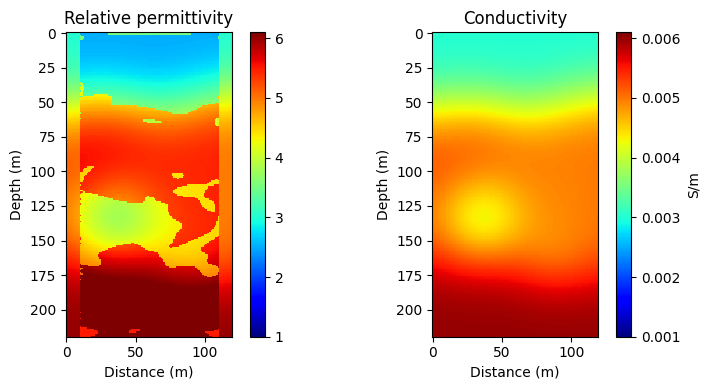

Epoch 1, Loss: 1137410304.00, Epoch Time: 0.81s, Total Time: 1.98s
Epoch 2, Loss: 991914624.00, Epoch Time: 0.80s, Total Time: 2.78s
Epoch 3, Loss: 965263168.00, Epoch Time: 0.81s, Total Time: 3.59s
Epoch 4, Loss: 716507712.00, Epoch Time: 0.81s, Total Time: 4.40s
Epoch 5, Loss: 753219264.00, Epoch Time: 0.81s, Total Time: 5.21s
Epoch 6, Loss: 705575104.00, Epoch Time: 0.82s, Total Time: 6.03s
Epoch 7, Loss: 634889536.00, Epoch Time: 0.82s, Total Time: 6.85s
Epoch 8, Loss: 585767360.00, Epoch Time: 0.81s, Total Time: 7.66s
Epoch 9, Loss: 500300640.00, Epoch Time: 0.80s, Total Time: 8.46s
Epoch 10, Loss: 487301024.00, Epoch Time: 0.80s, Total Time: 9.26s
Epoch 11, Loss: 497588128.00, Epoch Time: 0.80s, Total Time: 10.06s
Epoch 12, Loss: 450768704.00, Epoch Time: 0.79s, Total Time: 10.85s
Epoch 13, Loss: 390267456.00, Epoch Time: 0.81s, Total Time: 11.67s
Epoch 14, Loss: 379333696.00, Epoch Time: 0.80s, Total Time: 12.47s
Epoch 15, Loss: 395027712.00, Epoch Time: 0.81s, Total Time: 13.28

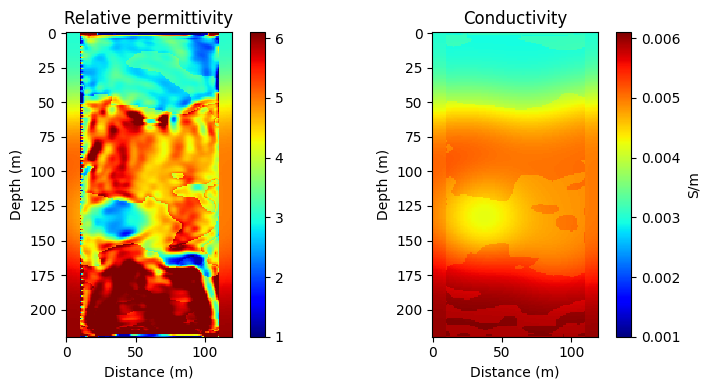

Epoch 51, Loss: 782805184.00, Epoch Time: 0.81s, Total Time: 42.83s
Epoch 52, Loss: 426459808.00, Epoch Time: 0.81s, Total Time: 43.64s
Epoch 53, Loss: 376259840.00, Epoch Time: 0.82s, Total Time: 44.45s
Epoch 54, Loss: 440656864.00, Epoch Time: 0.80s, Total Time: 45.26s
Epoch 55, Loss: 282730592.00, Epoch Time: 0.80s, Total Time: 46.06s
Epoch 56, Loss: 246966256.00, Epoch Time: 0.81s, Total Time: 46.87s
Epoch 57, Loss: 318910272.00, Epoch Time: 0.81s, Total Time: 47.68s
Epoch 58, Loss: 229141968.00, Epoch Time: 0.82s, Total Time: 48.50s
Epoch 59, Loss: 170038960.00, Epoch Time: 0.81s, Total Time: 49.30s
Epoch 60, Loss: 247609472.00, Epoch Time: 0.82s, Total Time: 50.12s
Epoch 61, Loss: 184813584.00, Epoch Time: 0.80s, Total Time: 50.92s
Epoch 62, Loss: 164442992.00, Epoch Time: 0.81s, Total Time: 51.73s
Epoch 63, Loss: 216155616.00, Epoch Time: 0.79s, Total Time: 52.52s
Epoch 64, Loss: 161745616.00, Epoch Time: 0.81s, Total Time: 53.33s
Epoch 65, Loss: 149699920.00, Epoch Time: 0.80s,

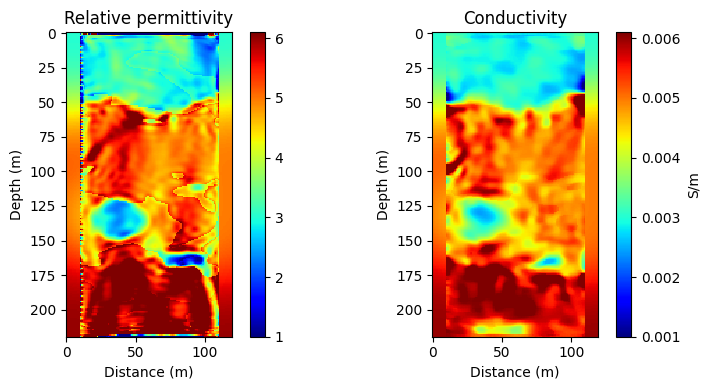

Epoch 101, Loss: 58874740.00, Epoch Time: 0.80s, Total Time: 83.66s
Epoch 102, Loss: 74632424.00, Epoch Time: 0.83s, Total Time: 84.49s
Epoch 103, Loss: 68832872.00, Epoch Time: 0.80s, Total Time: 85.30s
Epoch 104, Loss: 67615376.00, Epoch Time: 0.82s, Total Time: 86.12s
Epoch 105, Loss: 81150528.00, Epoch Time: 0.81s, Total Time: 86.92s
Epoch 106, Loss: 62747596.00, Epoch Time: 0.82s, Total Time: 87.74s
Epoch 107, Loss: 86944088.00, Epoch Time: 0.81s, Total Time: 88.55s
Epoch 108, Loss: 68832456.00, Epoch Time: 0.81s, Total Time: 89.36s
Epoch 109, Loss: 94613408.00, Epoch Time: 0.81s, Total Time: 90.18s
Epoch 110, Loss: 80387384.00, Epoch Time: 0.81s, Total Time: 90.98s
Epoch 111, Loss: 79533616.00, Epoch Time: 0.81s, Total Time: 91.79s
Epoch 112, Loss: 75410808.00, Epoch Time: 0.80s, Total Time: 92.60s
Epoch 113, Loss: 79561496.00, Epoch Time: 0.81s, Total Time: 93.40s
Epoch 114, Loss: 85146472.00, Epoch Time: 0.80s, Total Time: 94.21s
Epoch 115, Loss: 73423152.00, Epoch Time: 0.80s,

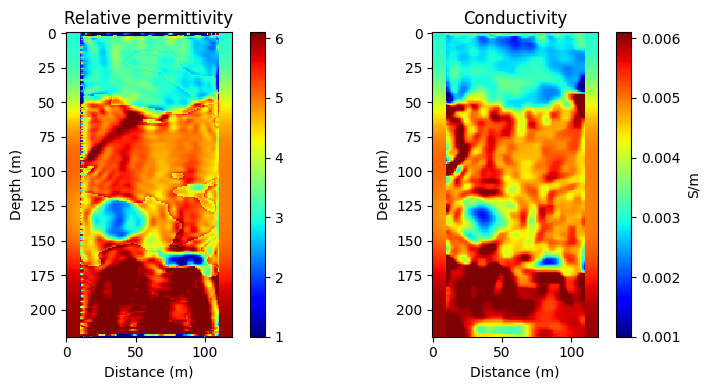

Epoch 151, Loss: 78371424.00, Epoch Time: 0.81s, Total Time: 124.59s
Epoch 152, Loss: 94779256.00, Epoch Time: 0.81s, Total Time: 125.39s
Epoch 153, Loss: 84595728.00, Epoch Time: 0.81s, Total Time: 126.21s
Epoch 154, Loss: 93570824.00, Epoch Time: 0.82s, Total Time: 127.02s
Epoch 155, Loss: 88674544.00, Epoch Time: 0.82s, Total Time: 127.84s
Epoch 156, Loss: 83754864.00, Epoch Time: 0.80s, Total Time: 128.64s
Epoch 157, Loss: 81485968.00, Epoch Time: 0.80s, Total Time: 129.45s
Epoch 158, Loss: 84410888.00, Epoch Time: 0.80s, Total Time: 130.25s
Epoch 159, Loss: 77024984.00, Epoch Time: 0.81s, Total Time: 131.06s
Epoch 160, Loss: 84304128.00, Epoch Time: 0.82s, Total Time: 131.88s
Epoch 161, Loss: 73662248.00, Epoch Time: 0.82s, Total Time: 132.70s
Epoch 162, Loss: 94801672.00, Epoch Time: 0.81s, Total Time: 133.51s
Epoch 163, Loss: 77939496.00, Epoch Time: 0.82s, Total Time: 134.34s
Epoch 164, Loss: 98775992.00, Epoch Time: 0.80s, Total Time: 135.14s
Epoch 165, Loss: 94190888.00, Epoc

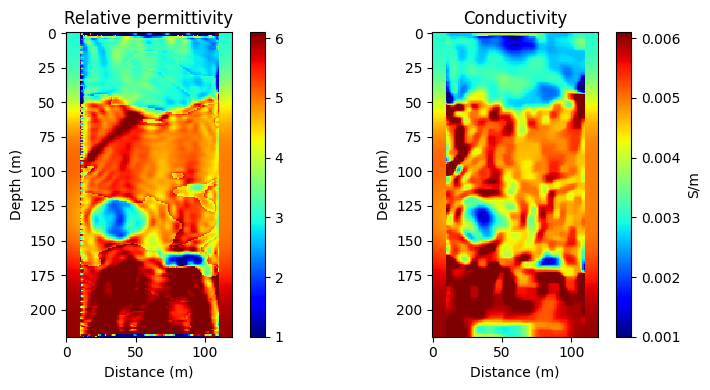

In [ ]:
for epoch in range(n_epochs):
    if epoch < phase1_epochs:
        current_optimizer = optimiser_phase1
        se.requires_grad = False 
        er.requires_grad = True  
    else:
        current_optimizer = optimiser_phase2
        se.requires_grad = True    
        er.requires_grad = True   
    
    epoch_start = time.time()
    current_optimizer.zero_grad()

    r = DeepGPR1.compute(
        device=device, dx=dx, dt=dt, 
        source_amplitudes=source_amplitudes,
        source_location=source_location, 
        receiver_location=receiver_location, 
        er=er, se=se
    )
  
    loss = loss_fnl1(r[-1], r_obs[-1]) * 1e10
    loss.backward()
    tv_criterion(er, se).backward()
    if er.requires_grad:
        er.grad[:, :10,] = 0
        er.grad[:, -10:] = 0
    if se.requires_grad:
        se.grad[:, :10] = 0
        se.grad[:, -10:] = 0

    current_optimizer.step()
    losses.append(loss.item()) 
    epoch_time = time.time() - epoch_start  
    total_time = time.time() - start_time  
    with torch.no_grad():
        se.data.clamp_(min=0)
        er.data.clamp_(min=1)
    print(f"Epoch {epoch}, Loss: {loss.item():.2f}, Epoch Time: {epoch_time:.2f}s, Total Time: {total_time:.2f}s")
    if epoch % 50 == 0:
        fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
        im1 = axes[0].imshow(er.detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=ert.max(),vmin=ert.min())
        cbar1 = plt.colorbar(im1, ax=axes[0])
        axes[0].set_title('Relative permittivity')
        axes[0].set_xlabel('Distance (m)')
        axes[0].set_ylabel('Depth (m)')

        im2 = axes[1].imshow(se.detach().cpu().numpy(),
                            cmap='jet',
                            interpolation='nearest',
                            aspect='equal',vmax=set.max(),vmin=set.min())
        cbar2 = plt.colorbar(im2, ax=axes[1])
        cbar2.set_label('S/m')
        axes[1].set_title('Conductivity')
        axes[1].set_xlabel('Distance (m)')
        axes[1].set_ylabel('Depth (m)')

        plt.tight_layout()
        plt.show()